<a href="https://colab.research.google.com/github/yeshaa23/ZARA-AppsReview-SentimentAnalysis/blob/main/Week%204/ZARA_Review_Bag_of_Words.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ZARA Google Play Review - Bag of Words (BoW)

##Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from scipy.sparse import save_npz

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print('All libraries loaded successfully.')

All libraries loaded successfully.


##Load Preprocessed Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Load the cleaned dataset from the preprocessing notebook
df = pd.read_csv('/content/drive/MyDrive/Tugas-1A-PBA/text_preprocessed_review_zara.csv')

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: 13,139 rows x 14 columns
Columns: ['id', 'score', 'at', 'review', 'language', 'sentiment_rating', 'review_original', 'token', 'token_after_sr', 'cleaned_content', 'token_after_lemma', 'token_after_stem', 'sentiment_polarity', 'sentiment_subjective']


,id,score,at,review,language,sentiment_rating,review_original,token,token_after_sr,cleaned_content,token_after_lemma,token_after_stem,sentiment_polarity,sentiment_subjective
0,1,1,2026-03-30 05:33:51,everytime i try to use it the app starts to up...,en,Negative,everytime I try to use it the app starts to up...,"['everytime', 'i', 'try', 'to', 'use', 'it', '...","['everytime', 'try', 'use', 'starts', 'update'...",everytime try use start update not believe guy...,"['everytime', 'try', 'use', 'start', 'update',...","['everytim', 'tri', 'use', 'start', 'updat', '...",-0.377778,0.888889
1,2,5,2026-03-30 05:00:24,smooth online purchase,en,Positive,smooth online purchase,"['smooth', 'online', 'purchase']","['smooth', 'online', 'purchase']",smooth online purchase,"['smooth', 'online', 'purchase']","['smooth', 'onlin', 'purchas']",0.400000,0.500000
2,3,5,2026-03-29 21:28:12,easy app to use,en,Positive,Easy app to use,"['easy', 'app', 'to', 'use']","['easy', 'use']",easy use,"['easy', 'use']","['easi', 'use']",0.433333,0.833333
3,4,5,2026-03-29 10:04:34,great service thanks,en,Positive,"great service, thanks","['great', 'service', 'thanks']","['great', 'service', 'thanks']",great service thanks,"['great', 'service', 'thanks']","['great', 'servic', 'thank']",0.500000,0.475000
4,5,2,2026-03-29 09:58:21,website a nightmare to make a payment,en,Negative,website a nightmare to make a payment.,"['website', 'a', 'nightmare', 'to', 'make', 'a...","['website', 'nightmare', 'make', 'payment']",website nightmare make payment,"['website', 'nightmare', 'make', 'payment']","['websit', 'nightmar', 'make', 'payment']",0.000000,0.000000


##Explore the Cleaned Text

In [4]:
# Check for missing or empty values in cleaned_content
missing = df['cleaned_content'].isna().sum()
empty   = (df['cleaned_content'].str.strip() == '').sum()

print(f'Missing values : {missing}')
print(f'Empty strings  : {empty}')

# Drop rows with missing or empty cleaned_content
df = df.dropna(subset=['cleaned_content'])
df = df[df['cleaned_content'].str.strip() != '']
df = df.reset_index(drop=True)

print(f'\nAfter cleaning : {df.shape[0]:,} rows')

Missing values : 11
Empty strings  : 0

After cleaning : 13,128 rows


Word count statistics:
count    13128.00
mean         9.02
std          9.68
min          1.00
25%          3.00
50%          5.00
75%         12.00
max        147.00
Name: word_count, dtype: float64


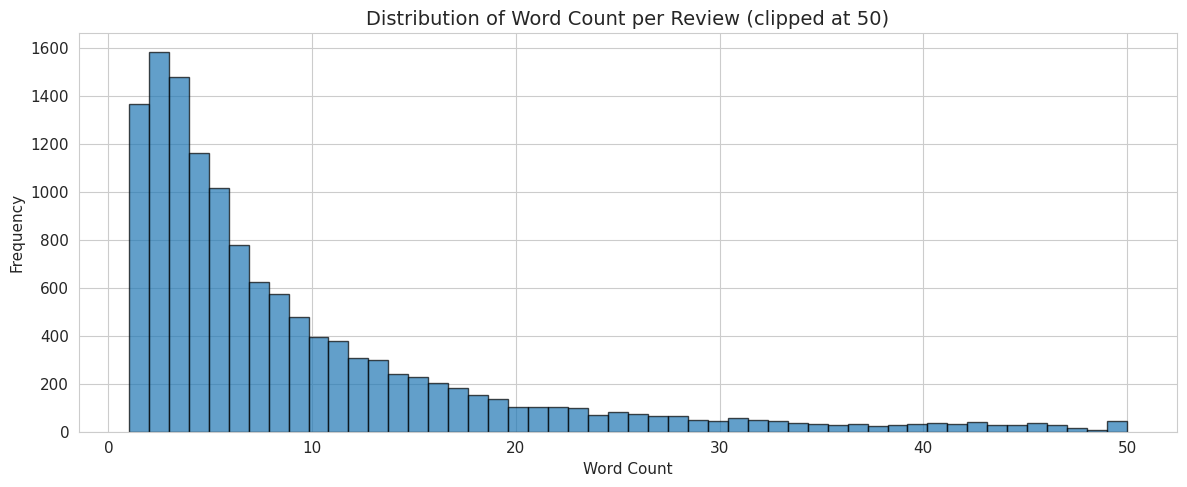

In [5]:
# Word count distribution
df['word_count'] = df['cleaned_content'].apply(lambda x: len(str(x).split()))

print('Word count statistics:')
print(df['word_count'].describe().round(2))

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
df['word_count'].clip(upper=50).hist(bins=50, ax=ax, edgecolor='black', alpha=0.7)
ax.set_title('Distribution of Word Count per Review (clipped at 50)', fontsize=14)
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [6]:
# Sample some cleaned reviews
print('Sample cleaned reviews:')
print('=' * 80)
for _, row in df[['cleaned_content', 'sentiment_rating']].sample(5, random_state=42).iterrows():
    print(f'  [{row["sentiment_rating"]}] {row["cleaned_content"][:100]}')
    print()

Sample cleaned reviews:
  [Negative] zara employee racist boycott

  [Negative] poor used fine since updated last week lost account history unable trace order placed

  [Positive] waitingfor impression

  [Positive] fast easy

  [Positive] one word brilliant



##Build Bag of Words Model

In [7]:
# Initialize CountVectorizer
# Since text is already preprocessed (lowercased, tokenized, stopwords removed, stemmed),
# we use minimal settings here.
bow_vectorizer = CountVectorizer(
    analyzer='word',
    token_pattern=r'\b\w+\b',
    min_df=2,
    max_df=0.95,
)

# Fit and transform the cleaned text
bow_matrix = bow_vectorizer.fit_transform(df['cleaned_content'])

print(f'BoW Matrix Shape : {bow_matrix.shape}')
print(f'  - Documents    : {bow_matrix.shape[0]:,}')
print(f'  - Vocabulary   : {bow_matrix.shape[1]:,} unique terms')
print(f'  - Non-zero     : {bow_matrix.nnz:,} entries')
print(f'  - Sparsity     : {(1 - bow_matrix.nnz / (bow_matrix.shape[0] * bow_matrix.shape[1])) * 100:.4f}%')

BoW Matrix Shape : (13128, 3721)
  - Documents    : 13,128
  - Vocabulary   : 3,721 unique terms
  - Non-zero     : 103,943 entries
  - Sparsity     : 99.7872%


##Inspect BoW Vocabulary

In [8]:
# Get vocabulary (word -> index mapping)
vocab = bow_vectorizer.get_feature_names_out()

print(f'Total vocabulary size: {len(vocab):,}')
print(f'\nFirst 20 terms : {list(vocab[:20])}')
print(f'Last 20 terms  : {list(vocab[-20:])}')

Total vocabulary size: 3,721

First 20 terms : ['aap', 'abd', 'abhi', 'ability', 'able', 'abruptly', 'absolute', 'absolutely', 'absurd', 'abu', 'abusing', 'abysmal', 'ac', 'acc', 'acceds', 'accept', 'acceptable', 'accepted', 'accepting', 'access']
Last 20 terms  : ['youtube', 'youuuuuu', 'yr', 'yup', 'z', 'zalando', 'zar', 'zara', 'zarachat', 'zarafor', 'zarah', 'zarai', 'zaras', 'zarathey', 'zero', 'zionism', 'zionist', 'zipper', 'zone', 'zoom']


In [9]:
# Compute total term frequencies across all documents
term_freq = np.asarray(bow_matrix.sum(axis=0)).flatten()

# Create a DataFrame of term frequencies
df_freq = pd.DataFrame({
    'term': vocab,
    'frequency': term_freq
}).sort_values('frequency', ascending=False).reset_index(drop=True)

print('Top 30 most frequent terms (BoW):')
print(df_freq.head(30).to_string(index=False))

Top 30 most frequent terms (BoW):
      term  frequency
       not       5791
      zara       2054
      item       1396
        no       1222
      good       1193
   product       1182
      love       1171
     order       1148
   service       1063
  customer       1016
      time        998
     great        996
      easy        948
       use        901
  shopping        888
    online        822
     worst        791
     store        729
experience        708
  delivery        693
      like        684
   clothes        662
      even        634
    return        608
       one        592
       get        567
    option        561
      best        552
       bad        549
    really        538


##Visualize Top Terms

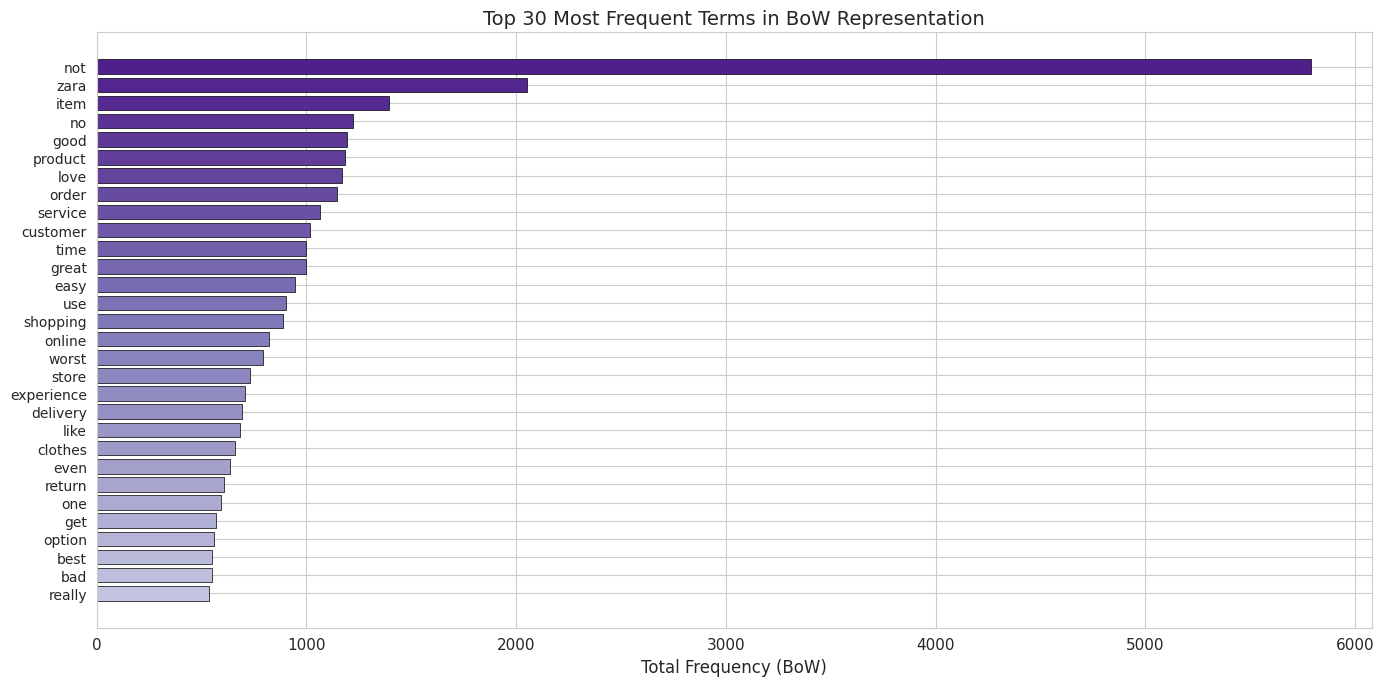

In [10]:
# Top 30 terms bar chart
top_n = 30
top_terms = df_freq.head(top_n)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(
    top_terms['term'][::-1],
    top_terms['frequency'][::-1],
    color=plt.cm.Purples(np.linspace(0.35, 0.9, top_n)),
    edgecolor='black',
    linewidth=0.5
)
ax.set_xlabel('Total Frequency (BoW)', fontsize=12)
ax.set_title(f'Top {top_n} Most Frequent Terms in BoW Representation', fontsize=14)
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.show()

Sentiment labels: ['Negative', 'Positive', 'Neutral']



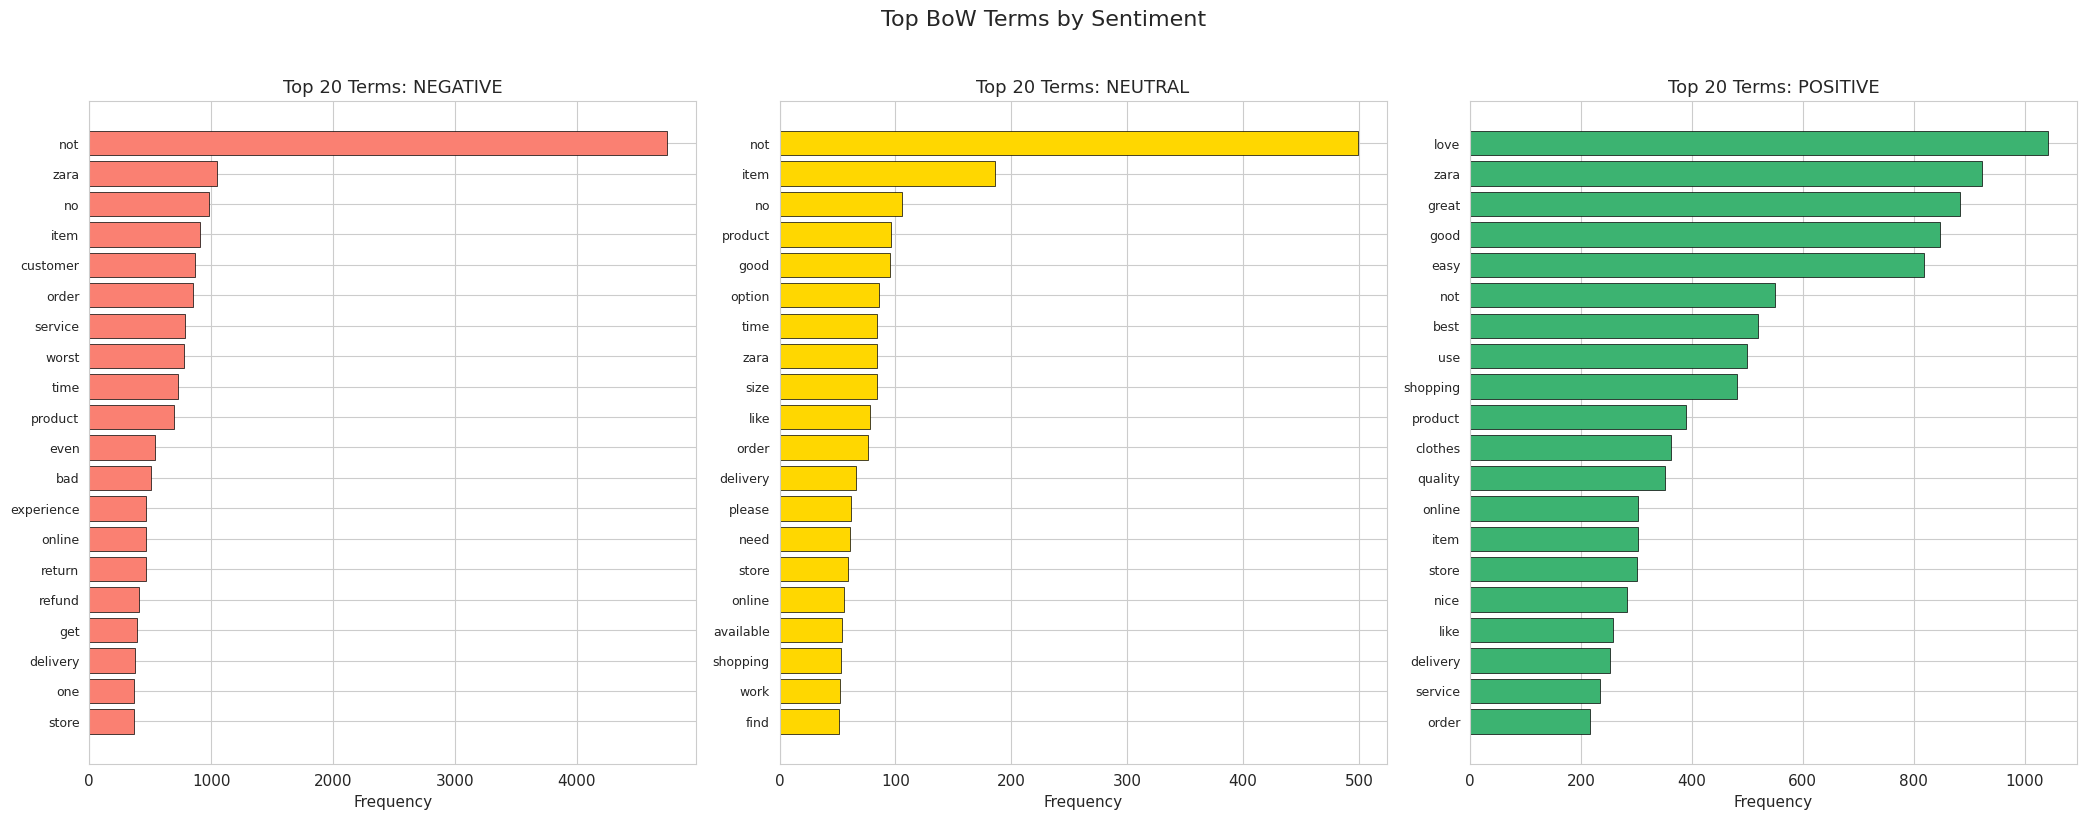

In [11]:
# Top terms by sentiment
sentiments = df['sentiment_rating'].unique()
print(f'Sentiment labels: {list(sentiments)}')
print()

fig, axes = plt.subplots(1, len(sentiments), figsize=(7 * len(sentiments), 8))
if len(sentiments) == 1:
    axes = [axes]

for ax, sentiment in zip(axes, sorted(sentiments)):
    mask = df['sentiment_rating'] == sentiment
    subset_matrix = bow_matrix[mask.values]
    subset_freq = np.asarray(subset_matrix.sum(axis=0)).flatten()

    top_idx = subset_freq.argsort()[::-1][:20]
    top_words = vocab[top_idx]
    top_counts = subset_freq[top_idx]

    ax.barh(
        top_words[::-1],
        top_counts[::-1],
        color='salmon' if sentiment == 'Negative' else ('gold' if sentiment == 'Neutral' else 'mediumseagreen'),
        edgecolor='black',
        linewidth=0.5
    )
    ax.set_title(f'Top 20 Terms: {sentiment.upper()}', fontsize=13)
    ax.set_xlabel('Frequency')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Top BoW Terms by Sentiment', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

##BoW Matrix Preview

In [12]:
# Find top 20 most frequent terms
term_freq = np.asarray(bow_matrix.sum(axis=0)).flatten()
top_20_idx = term_freq.argsort()[::-1][:20]
top_20_terms = vocab[top_20_idx]

# Preview BoW matrix using top 20 most frequent terms
preview_df = pd.DataFrame(
    bow_matrix[:10, top_20_idx].toarray(),
    columns=top_20_terms
)

print('BoW Matrix Preview (10 rows x top 20 frequent terms):')
preview_df

BoW Matrix Preview (10 rows x top 20 frequent terms):


,not,zara,item,no,good,product,love,order,service,customer,time,great,easy,use,shopping,online,worst,store,experience,delivery
0,3,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,2,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0
6,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
7,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0


## Analisis Regex
Insights Positive & Negative Reviews

In [13]:
import re

# Positive signals
positive_patterns = [
    r'\b(good|great|love|nice|best|amazing|excellent|perfect|helpful|easy)\b',
    r'\b(fast|smooth|quick|useful|comfortable|recommend)\b',
    r'\b(thank\s*you|thanks)\b',
    r'\b(convenient|simple|practical|works?\s*well)\b',
]

# Negative signals
negative_patterns = [
    r'\b(error|bug|crash|lag|slow|freeze|stuck|loading)\b',
    r'\b(bad|worst|awful|terrible|useless|disappointing)\b',
    r'\b(can\s*not|cannot|can\'t|not\s*working|doesn\'t\s*work)\b',
    r'\b(problem|issue|fail|failed|broken)\b',
    r'\b(uninstall|delete|remove)\b',
    r'\b(login\s*problem|payment\s*problem|checkout\s*problem)\b',
]

# Gabungkan menjadi satu pattern per kategori
pos_regex = re.compile('|'.join(positive_patterns), re.IGNORECASE)
neg_regex = re.compile('|'.join(negative_patterns), re.IGNORECASE)

print(f'Positive patterns: {len(positive_patterns)} grup')
print(f'Negative patterns: {len(negative_patterns)} grup')

Positive patterns: 4 grup
Negative patterns: 6 grup


In [14]:
# Terapkan regex ke kolom review asli
df['pos_matches'] = df['review'].astype(str).apply(
    lambda x: pos_regex.findall(x.lower())
)
df['neg_matches'] = df['review'].astype(str).apply(
    lambda x: neg_regex.findall(x.lower())
)

df['pos_count'] = df['pos_matches'].apply(len)
df['neg_count'] = df['neg_matches'].apply(len)

# Ringkasan
total_pos = df['pos_count'].sum()
total_neg = df['neg_count'].sum()
reviews_with_pos = (df['pos_count'] > 0).sum()
reviews_with_neg = (df['neg_count'] > 0).sum()

print('Hasil regex matching:')
print(f'  Review dengan sinyal positif : {reviews_with_pos:,} ({reviews_with_pos/len(df)*100:.1f}%)')
print(f'  Review dengan sinyal negatif : {reviews_with_neg:,} ({reviews_with_neg/len(df)*100:.1f}%)')
print(f'  Total match positif          : {total_pos:,}')
print(f'  Total match negatif          : {total_neg:,}')

Hasil regex matching:
  Review dengan sinyal positif : 4,989 (38.0%)
  Review dengan sinyal negatif : 3,186 (24.3%)
  Total match positif          : 6,690
  Total match negatif          : 4,155


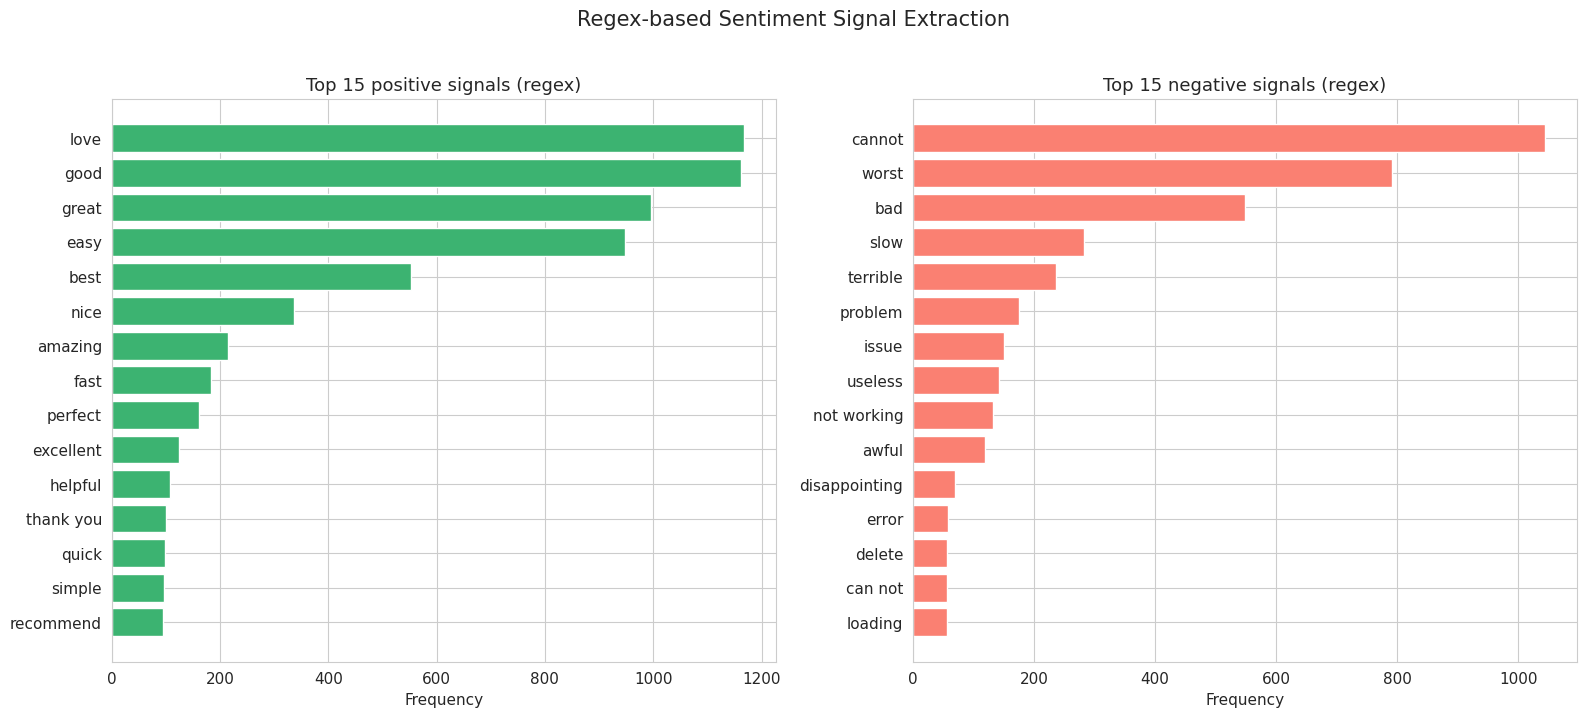

In [15]:
# Kata/frasa positif dan negatif paling sering ditemukan
from collections import Counter

all_pos = []
for list_of_match_tuples in df['pos_matches']:
    for match_tuple in list_of_match_tuples:
        if isinstance(match_tuple, (list, tuple)):
            all_pos.extend([s for s in match_tuple if s])
        elif match_tuple:
            all_pos.append(match_tuple)

all_neg = []
for list_of_match_tuples in df['neg_matches']:
    for match_tuple in list_of_match_tuples:
        if isinstance(match_tuple, (list, tuple)):
            all_neg.extend([s for s in match_tuple if s])
        elif match_tuple:
            all_neg.append(match_tuple)

pos_counter = Counter(all_pos).most_common(15)
neg_counter = Counter(all_neg).most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Positive
if pos_counter:
    words_p, counts_p = zip(*pos_counter)
    axes[0].barh(words_p[::-1], counts_p[::-1], color='mediumseagreen', edgecolor='white')
    axes[0].set_title('Top 15 positive signals (regex)', fontsize=13)
    axes[0].set_xlabel('Frequency')

# Negative
if neg_counter:
    words_n, counts_n = zip(*neg_counter)
    axes[1].barh(words_n[::-1], counts_n[::-1], color='salmon', edgecolor='white')
    axes[1].set_title('Top 15 negative signals (regex)', fontsize=13)
    axes[1].set_xlabel('Frequency')

plt.suptitle('Regex-based Sentiment Signal Extraction', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [16]:
# Validasi apakah regex selaras dengan label sentimen
df['regex_signal'] = 'none'
df.loc[df['pos_count'] > df['neg_count'], 'regex_signal'] = 'positive'
df.loc[df['neg_count'] > df['pos_count'], 'regex_signal'] = 'negative'
df.loc[(df['pos_count'] > 0) & (df['neg_count'] > 0) & (df['pos_count'] == df['neg_count']), 'regex_signal'] = 'mixed'

cross = pd.crosstab(df['sentiment_rating'], df['regex_signal'], margins=True)
print('Cross-tabulation: Sentiment Label vs Regex Signal')
print(cross)
print()

print('Contoh review dengan banyak sinyal NEGATIF:')
top_neg = df.nlargest(3, 'neg_count')[['review', 'sentiment_rating', 'neg_matches', 'neg_count']]
for _, row in top_neg.iterrows():
    print(f'  [{row["sentiment_rating"]}] (neg signals: {row["neg_count"]})')
    print(f'  {str(row["review"])[:120]}...')
    print(f'  Matches: {row["neg_matches"]}')
    print()

print('Contoh review dengan banyak sinyal POSITIF:')
top_pos = df.nlargest(3, 'pos_count')[['review', 'sentiment_rating', 'pos_matches', 'pos_count']]
for _, row in top_pos.iterrows():
    print(f'  [{row["sentiment_rating"]}] (pos signals: {row["pos_count"]})')
    print(f'  {str(row["review"])[:120]}...')
    print(f'  Matches: {row["pos_matches"]}')
    print()

print('Contoh review dengan sinyal MIXED:')
top_neutral = df[
    (df['regex_signal'] == 'mixed')
].head(3)[['review', 'sentiment_rating', 'pos_count', 'neg_count']]
for _, row in top_neutral.iterrows():
    print(f'  [{row["sentiment_rating"]}] (pos: {row["pos_count"]}, neg: {row["neg_count"]})')
    print(f'  {str(row["review"])[:120]}...')
    print()

Cross-tabulation: Sentiment Label vs Regex Signal
regex_signal      mixed  negative  none  positive    All
sentiment_rating                                        
Negative            171      2528  3327       422   6448
Neutral              39       174   523       204    940
Positive             78       123  1565      3974   5740
All                 288      2825  5415      4600  13128

Contoh review dengan banyak sinyal NEGATIF:
  [Negative] (neg signals: 6)
  the app is good but it have problem in payment cach on delivery or debit cardand customer service is so bad un friendly ...
  Matches: [('', '', '', 'problem', '', ''), ('', 'bad', '', '', '', ''), ('', '', 'cannot', '', '', ''), ('', '', '', 'problem', '', ''), ('', '', 'cannot', '', '', ''), ('', '', '', 'problem', '', '')]

  [Neutral] (neg signals: 5)
  not user friendly  there is token issue which is happening between app and the web every time you login into the app you...
  Matches: [('', '', '', 'issue', '', ''), ('',

In [17]:
# Bersihkan kolom temporary sebelum lanjut ke export
df = df.drop(columns=['pos_matches', 'neg_matches', 'pos_count', 'neg_count', 'regex_signal'], errors='ignore')

##Export BoW Artifacts

In [18]:
import pickle

# Save sparse BoW matrix
save_npz('zara_bow_matrix.npz', bow_matrix)
print('Saved: zara_bow_matrix.npz')

# Save vocabulary list
pd.DataFrame({'term': vocab}).to_csv('/content/drive/MyDrive/Tugas-1A-PBA/zara_bow_vocabulary.csv', index=False)
print('Saved: zara_bow_vocabulary.csv')

# Save term frequency table
df_freq.to_csv('zara_bow_term_frequencies.csv', index=False)
print('Saved: zara_bow_term_frequencies.csv')

# Save the fitted vectorizer
with open('zara_bow_vectorizer.pkl', 'wb') as f:
    pickle.dump(bow_vectorizer, f)
print('Saved: zara_bow_vectorizer.pkl')

print(f'\nBoW extraction complete.')
print(f'  Documents  : {bow_matrix.shape[0]:,}')
print(f'  Vocabulary : {bow_matrix.shape[1]:,} terms')
print(f'  Matrix     : {bow_matrix.nnz:,} non-zero entries')

Saved: zara_bow_matrix.npz
Saved: zara_bow_vocabulary.csv
Saved: zara_bow_term_frequencies.csv
Saved: zara_bow_vectorizer.pkl

BoW extraction complete.
  Documents  : 13,128
  Vocabulary : 3,721 terms
  Matrix     : 103,943 non-zero entries
